In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import gamma
import numpy as np
import missingno as msno


# 1) Exploración y comprensión de los datos:

- Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos:
<hr style="border:1px solid gray">

In [41]:
# Cargamos el dataset de los recorridos realidazos en 2024
df = pd.read_csv("../datasets/badata_ecobici_recorridos_realizados_2024.csv", encoding="utf-8")

# En el sitio web de la BA data se encuentran disponibles los recorridos desde 2018, 
# los datos parciales de 2025. Cargamos el últimmo año completo.
# https://data.buenosaires.gob.ar/dataset/bicicletas-publicas

- Describir las características principales del dataset, incluyendo el número de
observaciones, número de variables y tipos de datos:
<hr style="border:1px solid gray">

In [42]:
print("Dimensiones del dataset:", df.shape)
print("Head:")
display(df.head())

print("Tail:")
display(df.tail())

print("Info:")
print(df.info())

Dimensiones del dataset: (3559284, 17)
Head:


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


Tail:


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
3559279,21526830,506,2024-04-25 21:35:33,93,093 - CARLOS CALVO,Sarandi 1010,-58.394464,-34.620798,2024-04-25 21:43:59,175,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,1124148.0,ICONIC,MALE
3559280,21525192,970,2024-04-25 17:34:30,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-04-25 17:50:40,93,093 - CARLOS CALVO,Sarandi 1010,-58.394464,-34.620798,1124148.0,FIT,MALE
3559281,21525370,1442,2024-04-25 17:45:12,263,270 - PLAZA DEL ANGEL GRIS,Calcena & Avellaneda Av.,-58.457555,-34.622003,2024-04-25 18:09:14,263,270 - PLAZA DEL ANGEL GRIS,Calcena & Avellaneda Av.,-58.457555,-34.622003,870169.0,FIT,MALE
3559282,21526289,520,2024-04-25 19:28:49,222,160 - Godoy Cruz y Libertador,Av. Cerviño 4301,-58.418543,-34.575919,2024-04-25 19:37:29,124,124 - UGARTECHE,Juan María Gutiérrez 2069,-58.412625,-34.581114,222965.0,ICONIC,FEMALE
3559283,21522073,982,2024-04-25 13:13:10,517,332 - PACÍFICO II,Av. Int. Bullrich 300,-58.424814,-34.574501,2024-04-25 13:29:32,50,050 - Hospital Rivadavia,2516 Pereyra Lucena,-58.401080,-34.583735,1148648.0,ICONIC,FEMALE


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3559284 entries, 0 to 3559283
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      object 
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      object 
 5   direccion_estacion_origen   object 
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     object 
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     object 
 11  direccion_estacion_destino  object 
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            object 
 16  genero                      object 
dtypes: float64(5), int64(4), object(8)
memory usage: 461.6+ MB
None


In [43]:
print("Valores nulos por columna:")
print(df.isna().sum())

Valores nulos por columna:
id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino               0
nombre_estacion_destino           0
direccion_estacion_destino        0
long_estacion_destino             0
lat_estacion_destino              0
id_usuario                        0
modelo_bicicleta                  0
genero                        11946
dtype: int64


| Variable                     | Descripción                                                         |Tipo de Variable   |Ejemplo                                     |
| ---------------------------- | ------------------------------------------------------------------- |------------------ |------------------------------------------- |
| `id_recorrido`               | Identificador único de cada recorrido                               |Numérica discreta*  |20428222                                    |
| `duracion_recorrido`         | Duración del recorrido en **segundos**                              |Numérica continua  |568                     |
| `fecha_origen_recorrido`     | Fecha y hora de inicio del recorrido                                |Fecha / Temporal   |2024-01-23 18:36:00                         |
| `id_estacion_origen`         | Identificador numérico de la estación de origen                     |Numérica discreta  |513                                         |
| `nombre_estacion_origen`     | Nombre de la estación de origen (`ID - NOMBRE`)                     |Categórica nominal |308 - SAN MARTIN II                         |
| `direccion_estacion_origen`  | Dirección de la estación de origen                                  |Categórica nominal |Av. San Martín 5129                         |
| `long_estacion_origen`       | Longitud geográfica de la estación de origen (Sistema Geodésico Mundial) | Numérica continua  |    -58.490739       |
| `lat_estacion_origen`        | Latitud geográfica de la estación de origen                         |Numérica continua  |-34.597130                                  |
| `fecha_destino_recorrido`    | Fecha y hora de fin del recorrido (puede ser nulo si quedó abierto) |Fecha / Temporal   |2024-01-23 18:45:28           |
| `id_estacion_destino`        | Identificador numérico de la estación de destino                    |Numérica discreta  |498                                         |
| `nombre_estacion_destino`    | Nombre de la estación de destino (`ID - NOMBRE`)                    |Categórica nominal |055 - HABANA                                |
| `direccion_estacion_destino` | Dirección de la estación de destino                                 |Categórica nominal |Gral. José Gervasio Artigas 4298 (y Habana) |
| `long_estacion_destino`      | Longitud geográfica de la estación de destino                       |Numérica continua  |-58.494959                                  |
| `lat_estacion_destino`       | Latitud geográfica de la estación de destino                        |Numérica continua  |-34.586598                                  |
| `id_usuario`                 | Identificador numérico del usuario (no es el DNI)                   |Numérica discreta  |992557.0                                    |
| `modelo_bicicleta`           | Modelo de la bicicleta utilizada (ej: `FIT`, `ICONIC`)              |Categórica nominal |FIT                                         |
| `genero`                     | Género declarado del usuario (`MALE`, `FEMALE`, `OTHER`, null)      |Categórica nominal |MALE                         |



- Identificar patrones generales y distribuciones:
<hr style="border:1px solid gray">

In [44]:
print("Estadística descriptiva del dataset:\n", df.describe())

Estadística descriptiva del dataset:
        id_recorrido  duracion_recorrido  id_estacion_origen  \
count  3.559284e+06        3.559284e+06        3.559284e+06   
mean   2.234123e+07        1.274827e+03        2.356064e+02   
std    1.257090e+06        9.584216e+03        1.657994e+02   
min    2.018097e+07        0.000000e+00        2.000000e+00   
25%    2.123850e+07        4.930000e+02        9.300000e+01   
50%    2.235117e+07        8.810000e+02        1.990000e+02   
75%    2.343694e+07        1.474000e+03        3.780000e+02   
max    2.450328e+07        2.571165e+06        5.770000e+02   

       long_estacion_origen  lat_estacion_origen  id_estacion_destino  \
count          3.559284e+06         3.559284e+06         3.559284e+06   
mean          -5.842301e+01        -3.459876e+01         2.371497e+02   
std            3.828674e-02         2.440911e-02         1.657102e+02   
min           -5.852710e+01        -3.468777e+01         2.000000e+00   
25%           -5.844965e+01  

In [45]:
# Revisemos las variables numéricas 

# las columnas de fechas están en formato string, las convertiremos a datetime.
df["fecha_origen_recorrido"] = pd.to_datetime(df["fecha_origen_recorrido"])
df["fecha_destino_recorrido"] = pd.to_datetime(df["fecha_destino_recorrido"])

# columnas dia-semana y hora para visualizar algunos datos por día y hora
df["dia_semana"] = df["fecha_origen_recorrido"].dt.day_name()
df["hora_salida"] = df["fecha_origen_recorrido"].dt.hour
df["hora_llegada"] = df["fecha_destino_recorrido"].dt.hour
df["duracion_minutos"] = df["duracion_recorrido"] / 60

# Seleccionar variables numéricas
numeric_cols = ["duracion_minutos", "hora_salida", 
                "hora_llegada", "id_usuario",
                "long_estacion_origen", "lat_estacion_origen",
                "long_estacion_destino", "lat_estacion_destino"]


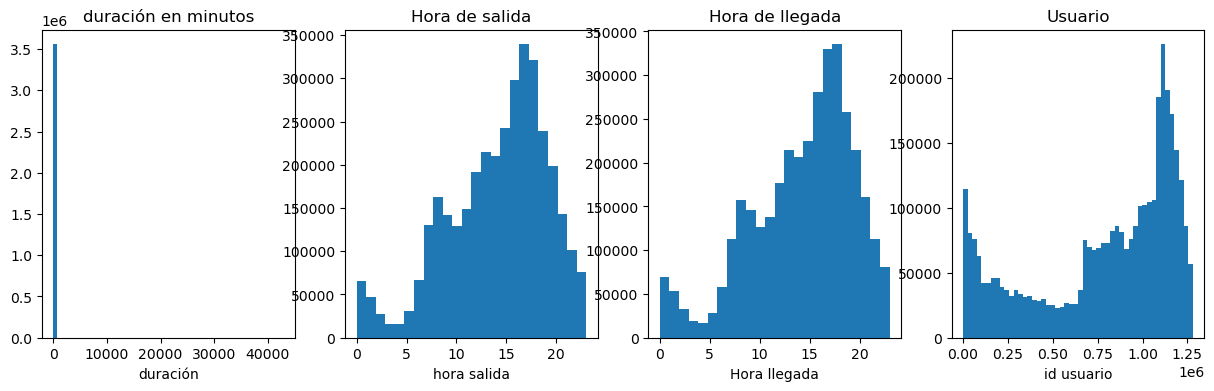

In [46]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

ax[0].hist(df['duracion_minutos'], bins=60)
ax[0].set_title('duración en minutos')
ax[0].set_xlabel('duración')
ax[1].hist(df['hora_salida'], bins=24)
ax[1].set_title('Hora de salida')
ax[1].set_xlabel('hora salida')
ax[2].hist(df['hora_llegada'], bins=24)
ax[2].set_title('Hora de llegada')
ax[2].set_xlabel('Hora llegada')
ax[3].hist(df['id_usuario'], bins=50)
ax[3].set_title('Usuario')
ax[3].set_xlabel('id usuario')

plt.show()

Text(0.5, 0, 'Lat destino')

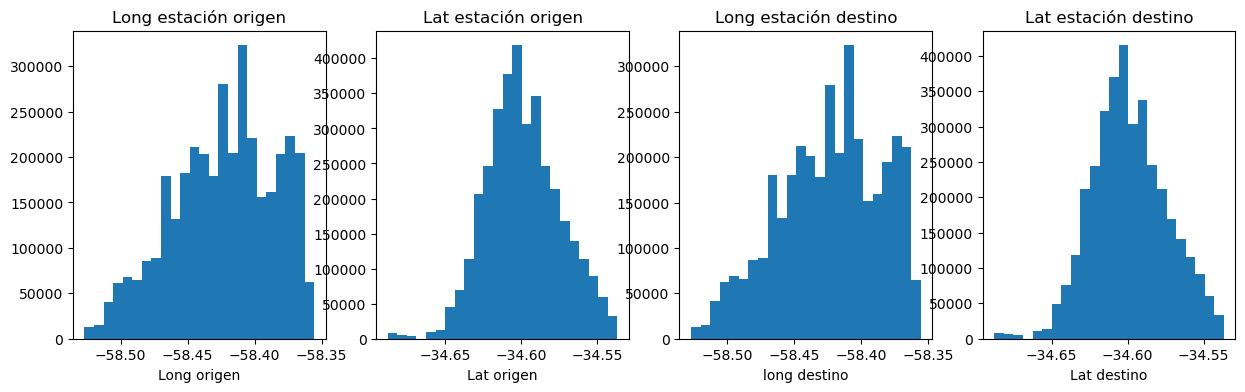

In [47]:
# Observamos que la duración se concentra en valores bajos, lo cual puede sugerir grandes outliers. 
# las horas de salida y llegada se correlacionan, con minimos y máximos claros. 

fig, ax = plt.subplots(1, 4, figsize=(15, 4))

ax[0].hist(df['long_estacion_origen'], bins=24)
ax[0].set_title('Long estación origen')
ax[0].set_xlabel('Long origen')
ax[1].hist(df['lat_estacion_origen'], bins=24)
ax[1].set_title('Lat estación origen')
ax[1].set_xlabel('Lat origen')
ax[2].hist(df['long_estacion_destino'], bins=24)
ax[2].set_title('Long estación destino')
ax[2].set_xlabel('long destino')
ax[3].hist(df['lat_estacion_destino'], bins=24)
ax[3].set_title('Lat estación destino')
ax[3].set_xlabel('Lat destino')

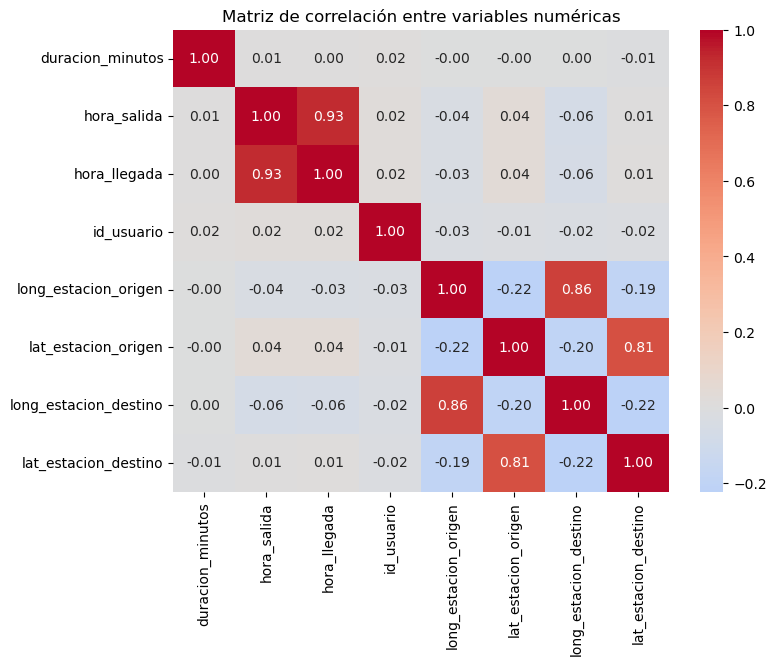

In [48]:
# Tamnbién hay distribuciones similares en las longitudes de origen y destino y latitudes de origen y destino.

# matriz de correlación
corr = df[numeric_cols].corr()

# Graficar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


# Vemos una correlación alta entre las longitudes de las estaciones de origen y destino
# y entre las latitudes de las estaciones de origen y destino.


In [49]:

df['nombre_estacion_origen'] = df['nombre_estacion_origen'].astype('category')
df['nombre_estacion_destino'] = df['nombre_estacion_destino'].astype('category')
df['direccion_estacion_origen'] = df['direccion_estacion_origen'].astype('category')
df['direccion_estacion_destino'] = df['direccion_estacion_destino'].astype('category')
df['modelo_bicicleta'] = df['modelo_bicicleta'].astype('category')
df['genero'] = df['genero'].astype('category')

df.describe(include='category')

,nombre_estacion_origen,direccion_estacion_origen,nombre_estacion_destino,direccion_estacion_destino,modelo_bicicleta,genero
count,3559284,3559284,3559284,3559284,3559284,3547338
unique,395,393,398,395,2,3
top,147 - Constitución,Avenida Juan de Garay 1050,147 - Constitución,Avenida Juan de Garay 1050,FIT,MALE
freq,38237,38237,38281,38281,2582443,2147721


Text(0.5, 1.0, 'Género')

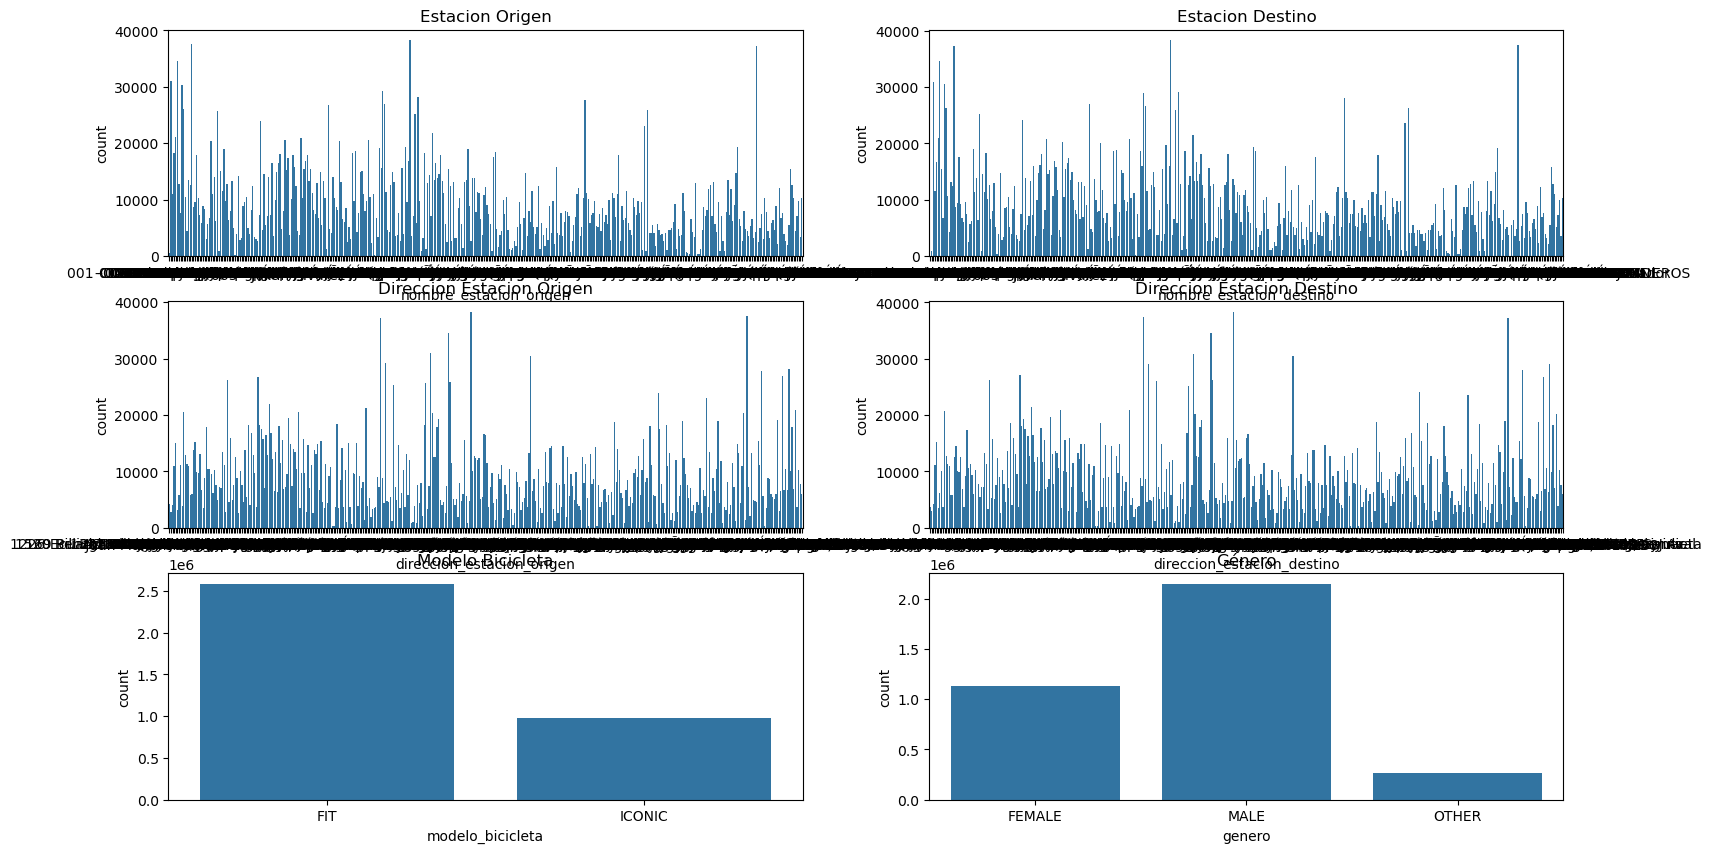

In [50]:
# Crear cada cajita
fig, ax = plt.subplots(3, 2, figsize=(18, 10))

# Gráficos de barras de cada una
sns.countplot(x='nombre_estacion_origen', data=df, ax=ax[0,0])
sns.countplot(x='nombre_estacion_destino', data=df, ax=ax[0,1])
sns.countplot(x='direccion_estacion_origen', data=df, ax=ax[1,0])
sns.countplot(x='direccion_estacion_destino', data=df, ax=ax[1,1])
sns.countplot(x='modelo_bicicleta', data=df, ax=ax[2,0])
sns.countplot(x='genero', data=df, ax=ax[2,1])

# Títulos
ax[0,0].set_title('Estacion Origen')
ax[0,1].set_title('Estacion Destino')
ax[1,0].set_title('Direccion Estacion Origen')
ax[1,1].set_title('Direccion Estacion Destino')
ax[2,0].set_title('Modelo Bicicleta')
ax[2,1].set_title('Género')

- Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR,
MNAR)
<hr style="border:1px solid gray">

In [51]:
# Quieremos ver los valores más comunes en cada columna categórica 

for col in df.columns:
    print(df[col].value_counts(dropna=False).head(10))

id_recorrido
22425357    2
20428222    1
23759939    1
23753515    1
23759549    1
23751172    1
23760548    1
23761887    1
23766205    1
23760426    1
Name: count, dtype: int64
duracion_recorrido
2     62889
22    59905
21    57906
0     37618
23     9760
25     8938
20     8269
28     7777
26     5516
27     3914
Name: count, dtype: int64
fecha_origen_recorrido
2024-01-24 19:37:35    13
2024-02-07 19:40:37    10
2024-08-07 18:04:20    10
2024-01-24 17:56:06    10
2024-02-16 19:49:11     9
2024-02-08 18:17:58     9
2024-01-23 20:19:13     8
2024-02-08 18:17:59     8
2024-11-04 18:43:26     8
2024-02-29 08:53:20     8
Name: count, dtype: int64
id_estacion_origen
175    38237
14     37594
516    37201
5      34547
202    30955
8      30400
130    29307
152    28197
289    27721
131    26967
Name: count, dtype: int64
nombre_estacion_origen
147 - Constitución             38237
014 - Pacifico                 37594
368 - PLAZA DE LA SHOÁ         37201
005 - Plaza Italia             34547
0

In [52]:
# Vemos que hay muchas duraciones de menos de un minuto.

# Veamos la proporcion de nulos
missing = df.isna().sum().reset_index()
missing.columns = ["columna", "nulos"]
missing["porcentaje"] = (missing["nulos"] / len(df)) * 100

# Quedarnos solo con las que tienen faltantes
missing = missing[missing["nulos"] > 0].sort_values("nulos", ascending=False)
missing


,columna,nulos,porcentaje
16,genero,11946,0.335629
8,fecha_destino_recorrido,3379,0.094935
19,hora_llegada,3379,0.094935


<Axes: >

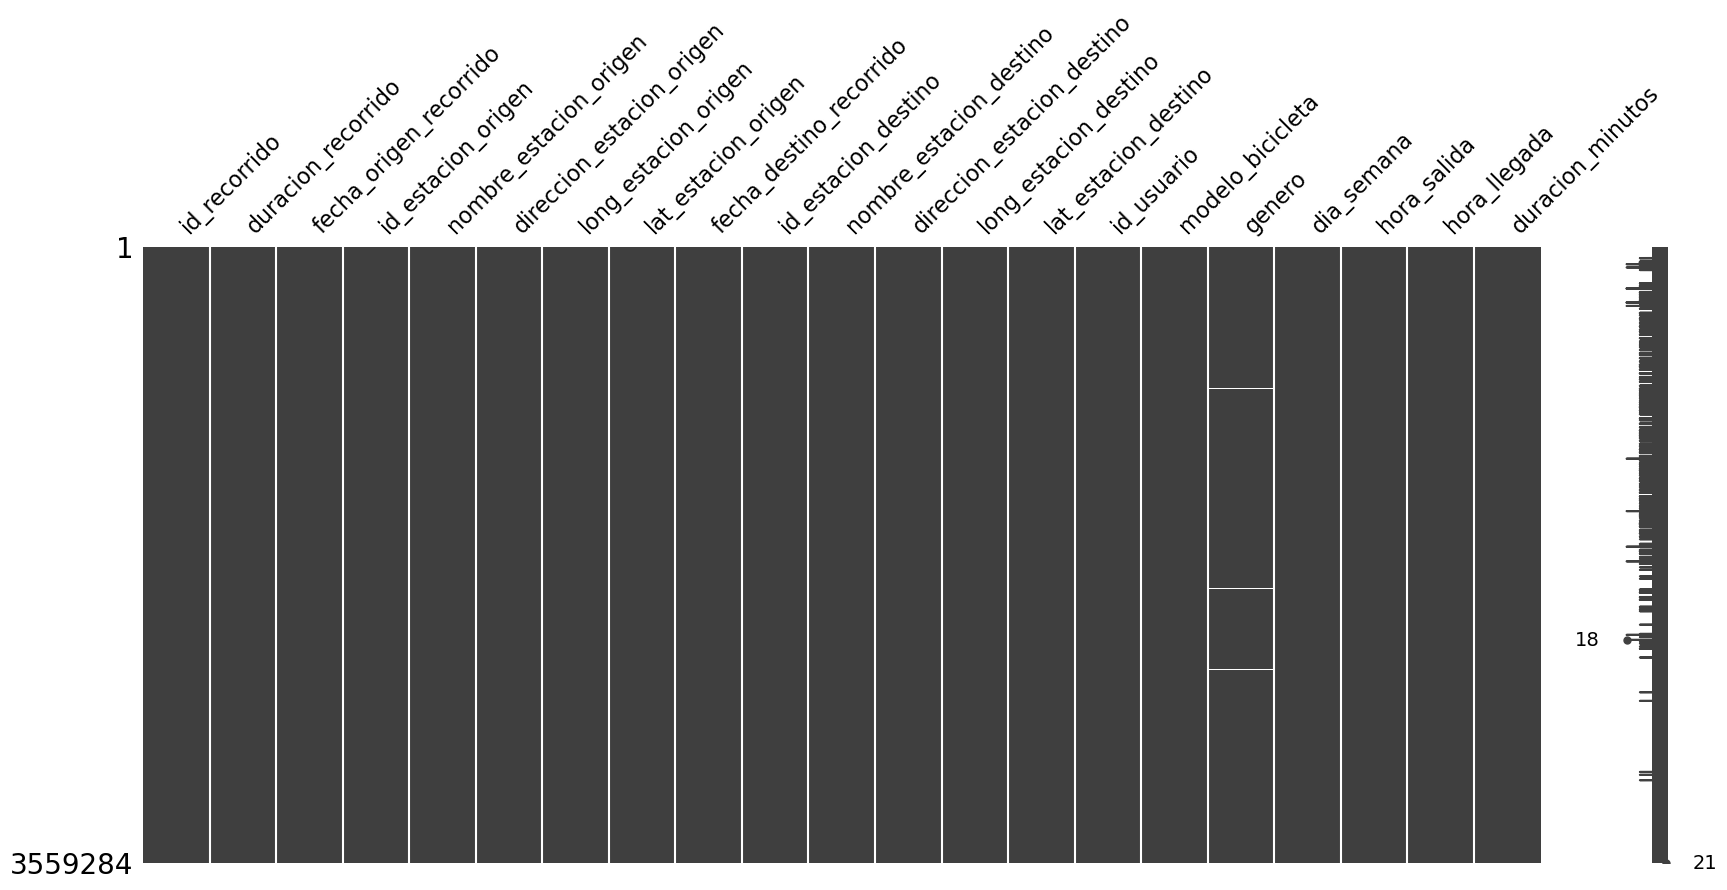

In [53]:
msno.matrix(df, figsize=(20,8))

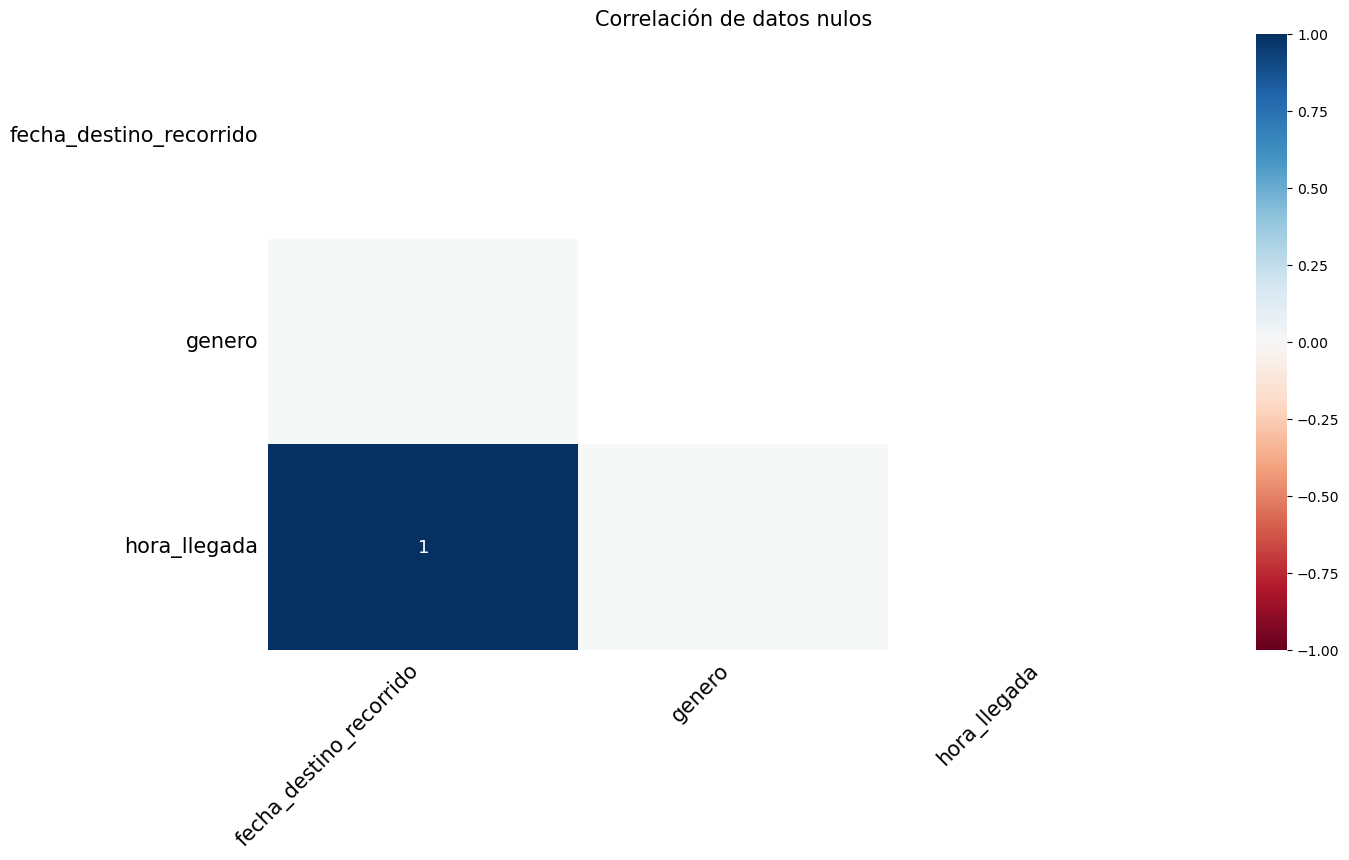

In [54]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

In [55]:
# Hay correlación de faltantes entre la fecha de destino y la duración calculada del recorrido, lo cual es esperable.

# Veamos máximos y mínimos
top_extremos = {}

for col in df.columns:
    try:
        top_min = df[col].nsmallest(10).values
        top_max = df[col].nlargest(10).values
        top_extremos[col] = {
            "minimos": top_min,
            "maximos": top_max
        }
    except (TypeError, ValueError):
        # Para columnas no numéricas, usamos value_counts
        top_min = df[col].value_counts().tail(10)
        top_max = df[col].value_counts().head(10)
        top_extremos[col] = {
            "menos_comunes": top_min,
            "mas_comunes": top_max
        }


for col, extremos in top_extremos.items():
    print(f"\n{col}")
    for tipo, vals in extremos.items():
        print(f"{tipo}:\n{vals}")



id_recorrido
minimos:
[20180969 20180970 20180971 20180972 20180973 20180974 20180975 20180976
 20180977 20180978]
maximos:
[24503283 24503282 24503281 24503280 24503279 24503278 24503277 24503276
 24503275 24503274]

duracion_recorrido
minimos:
[0 0 0 0 0 0 0 0 0 0]
maximos:
[2571165 2558708 2526519 2493287 2409444 2380862 2376978 2353295 2304825
 2286180]

fecha_origen_recorrido
minimos:
['2024-01-01T00:06:50.000000000' '2024-01-01T00:15:02.000000000'
 '2024-01-01T00:16:02.000000000' '2024-01-01T00:16:13.000000000'
 '2024-01-01T00:16:47.000000000' '2024-01-01T00:18:22.000000000'
 '2024-01-01T00:18:41.000000000' '2024-01-01T00:19:15.000000000'
 '2024-01-01T00:20:00.000000000' '2024-01-01T00:20:10.000000000']
maximos:
['2024-12-31T23:58:25.000000000' '2024-12-31T23:58:14.000000000'
 '2024-12-31T23:55:45.000000000' '2024-12-31T23:54:06.000000000'
 '2024-12-31T23:51:02.000000000' '2024-12-31T23:50:55.000000000'
 '2024-12-31T23:50:34.000000000' '2024-12-31T23:50:20.000000000'
 '2024-12-3

In [56]:
# Llama la atención la duración de viajes MUY altas.

# Veamos la proporción de outliers en las variables numéricas

num_cols = df.select_dtypes(include=[np.number]).columns

outliers_dict = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    outliers_dict[col] = df[col][mask]

# Mostrar resumen: cantidad de outliers por columna
for col, vals in outliers_dict.items():
    if (len (vals) > 0):
        print(f"{col}: {len(vals)} outliers ({len(vals)/len(df)*100:.2f}%)")

duracion_recorrido: 197787 outliers (5.56%)
lat_estacion_origen: 17843 outliers (0.50%)
lat_estacion_destino: 19863 outliers (0.56%)
hora_salida: 65528 outliers (1.84%)
hora_llegada: 69424 outliers (1.95%)
duracion_minutos: 197787 outliers (5.56%)


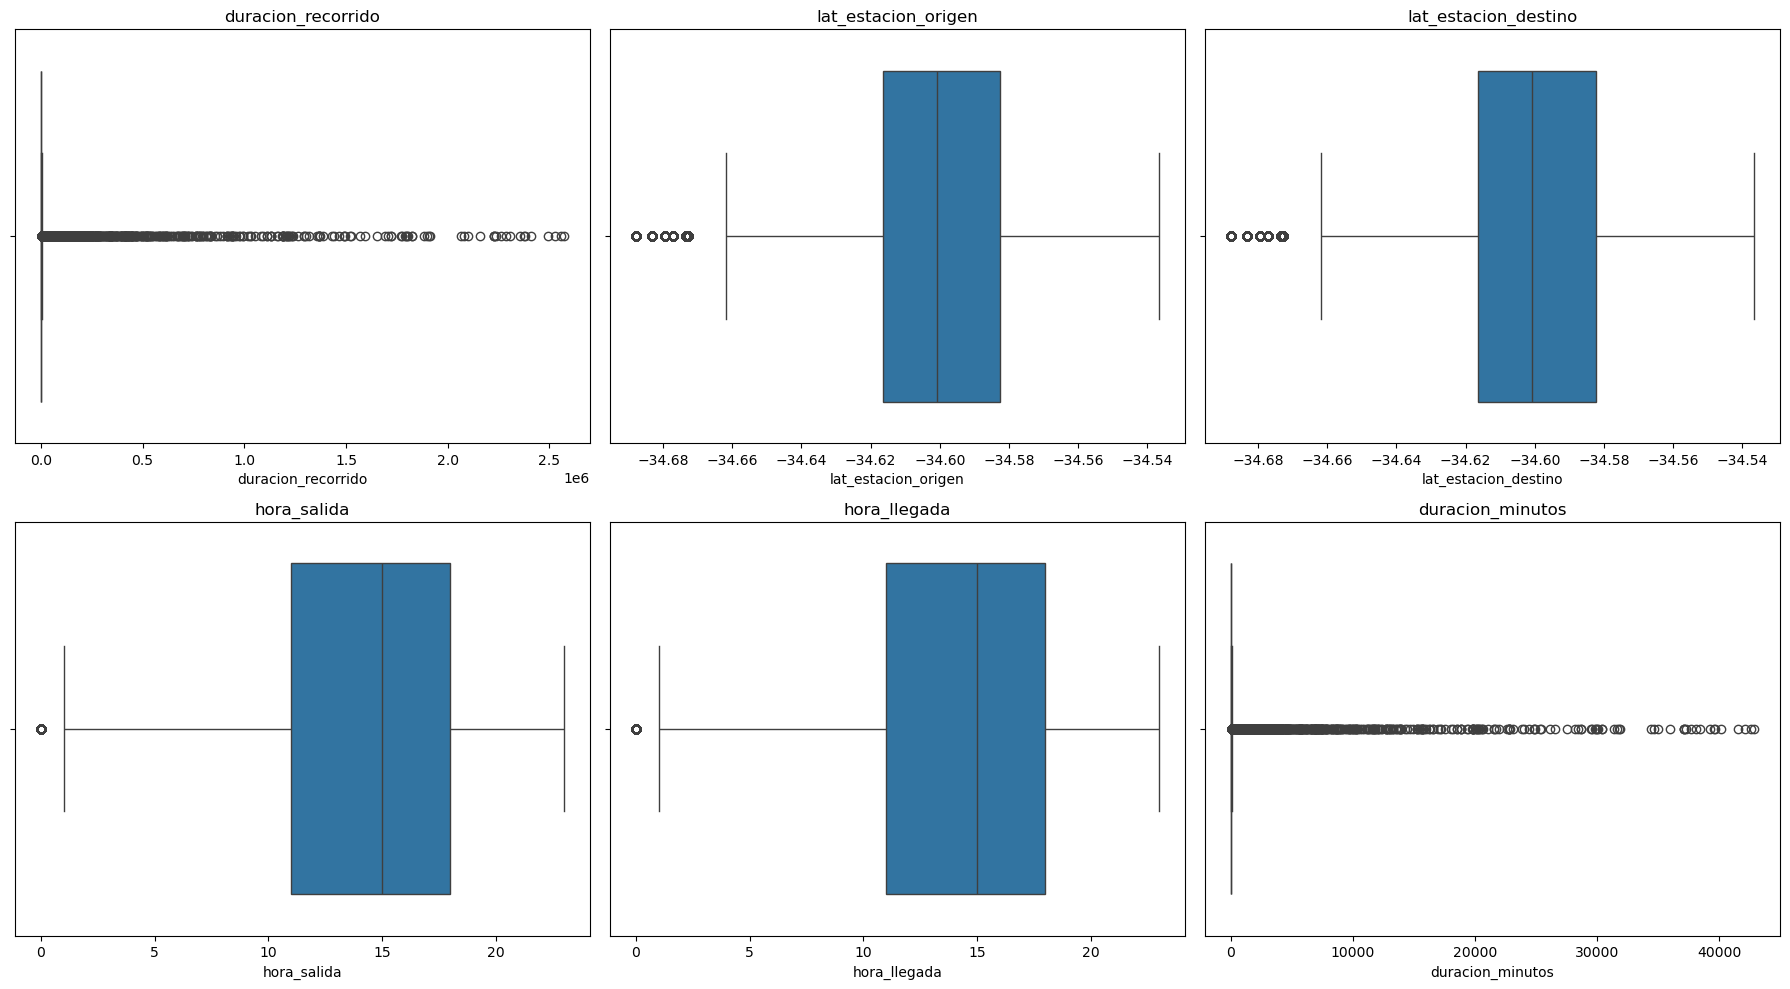

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(x=df["duracion_recorrido"], ax=axes[0, 0])
axes[0, 0].set_title("duracion_recorrido")

sns.boxplot(x=df["lat_estacion_origen"], ax=axes[0, 1])
axes[0, 1].set_title("lat_estacion_origen")

sns.boxplot(x=df["lat_estacion_destino"], ax=axes[0, 2])
axes[0, 2].set_title("lat_estacion_destino")

sns.boxplot(x=df["hora_salida"], ax=axes[1, 0])
axes[1, 0].set_title("hora_salida")

sns.boxplot(x=df["hora_llegada"], ax=axes[1, 1])
axes[1, 1].set_title("hora_llegada")

sns.boxplot(x=df["duracion_minutos"], ax=axes[1, 2])
axes[1, 2].set_title("duracion_minutos")

plt.tight_layout()
plt.show()


Outliers más destacados

- Viajes muy cortos (`duración_recorrido` < 30 segundos). Podrían ser viajes abortados por bicicletas en mal estado.
- Viajes muy largos (`duración_recorrido` > 2 horas) Pueden estar relacionados con fallas estructurales relacionadas con la recolección de la fecha de devolución por viajes abiertos, y actualizaciones manuales.
- Algunos outliers de latitud, pueden indicar que hay pocos viajes en las estaciones más al sur, lo cual tiene sentido porque hay pocas estaciones al suroeste.
- La hora es un campo calculado, y si bien aparecen algunos outliers, tiene sentido al ser una variable discreta de 0 a 23, donde el mínimo global ocurre cerca de las 3 y el máximo cerca de las 18 hs.


Valores faltantes y su tipo

- Hay 3379 registros sin `fecha_destino_recorrido` pero sí tienen id, long y lat de destino. (0.1%). Puede ser una falla estructural del registro de devoluciones. Pueden ser viajes sin destino porque nunca se cerraron, la ausencia tiene significado (no es aleatorio) MNAR 
- Hay 11946 registros sin género. Puede ser algo opcional en el registro. MCAR.



# 2) Aplicación de técnicas de visualización:

- Utilizar técnicas de visualización adecuadas para ilustrar las principales
características del dataset.
- Asegurarse de que las visualizaciones sean claras, concisas y efectivas para
comunicar la información.
- Interpretar los resultados obtenidos a partir de las visualizaciones.

Esto es algo que venimos haciendo. Otras visualizaciones interesantes a continuación.
<hr style="border:1px solid gray">

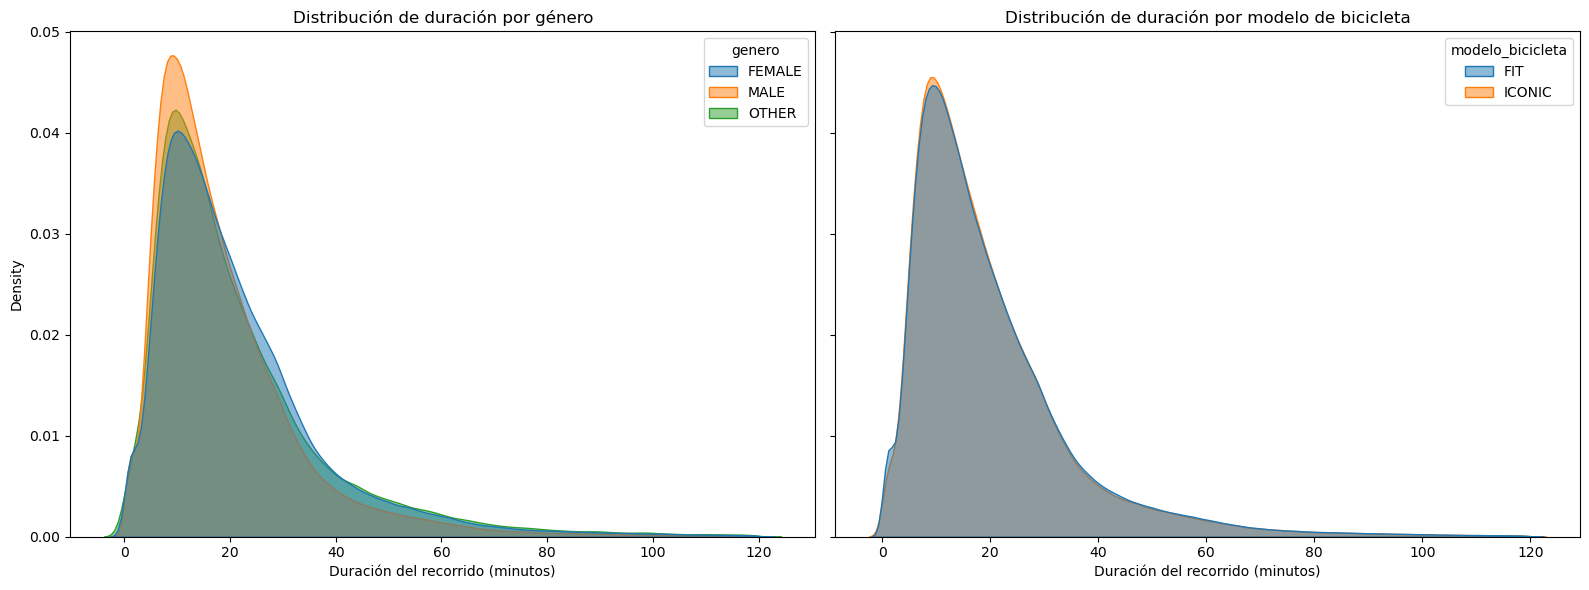

In [58]:
# Veamos si hay relaciones entre la duración de los viajes según el género o el modelo de bicicleta. 

# Se hace un filtrado de viajes razonables 
# porque parece haber muchos outliers

df_filtrado = df[(df["duracion_recorrido"] > 30) # al menos 1 minuto, porque hay muchos outliers que deben devoluciones inmediatas por bicicletas en estado defectuoso
                 &(df["duracion_recorrido"] < 7200)
                ] # analizar los de más de 2 horas 

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Distribución por género
sns.kdeplot(
    data=df_filtrado, 
    x='duracion_minutos', 
    hue='genero', 
    fill=True, 
    common_norm=False, 
    alpha=0.5, 
    ax=axes[0]
)
axes[0].set_title("Distribución de duración por género")
axes[0].set_xlabel("Duración del recorrido (minutos)")

# Distribución por modelo de bicicleta
sns.kdeplot(
    data=df_filtrado, 
    x='duracion_minutos', 
    hue='modelo_bicicleta', 
    fill=True, 
    common_norm=False, 
    alpha=0.5, 
    ax=axes[1]
)
axes[1].set_title("Distribución de duración por modelo de bicicleta")
axes[1].set_xlabel("Duración del recorrido (minutos)")

plt.tight_layout()
plt.show()


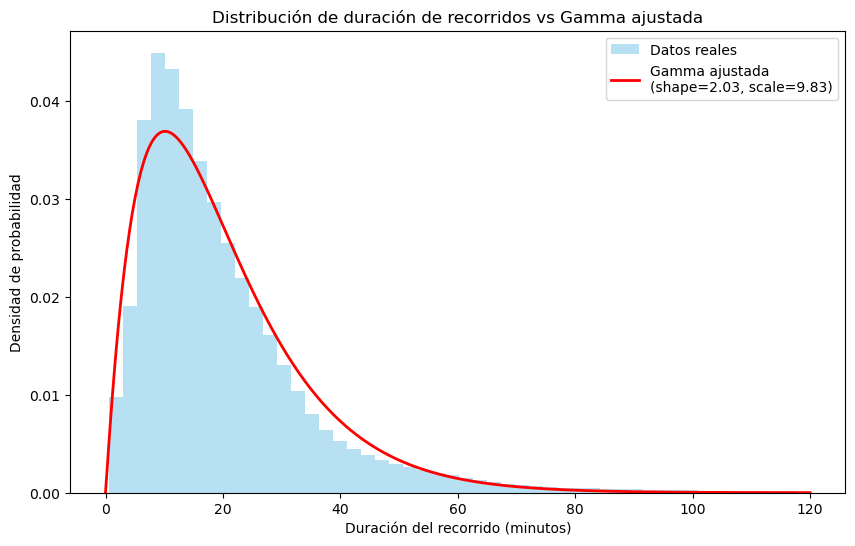

In [59]:
# A simple vista no se relacionan.

# Veamos la distribución de la duración de los viajes y ajustemos una distribución teórica.

duraciones = df["duracion_minutos"]

# Filtramos valores extremos (ejemplo: viajes mayores a 120 min)
duraciones = duraciones[(duraciones > 0.5) & (duraciones <= 120)]

# Ajustar distribución Gamma a los datos
shape, loc, scale = gamma.fit(duraciones, floc=0)  # floc=0 fija la localización en 0

# Crear rango de valores para graficar la curva teórica
x = np.linspace(0, duraciones.max(), 500)
pdf_gamma = gamma.pdf(x, shape, loc=loc, scale=scale)

# Graficar histograma y curva gamma ajustada
plt.figure(figsize=(10,6))
plt.hist(duraciones, bins=50, density=True, alpha=0.6, color="skyblue", label="Datos reales")
plt.plot(x, pdf_gamma, "r-", lw=2, label=f"Gamma ajustada\n(shape={shape:.2f}, scale={scale:.2f})")
plt.xlabel("Duración del recorrido (minutos)")
plt.ylabel("Densidad de probabilidad")
plt.title("Distribución de duración de recorridos vs Gamma ajustada")
plt.legend()
plt.show()

In [60]:
# Verifiquemos la dependencia lineal entre la duracion_recorrido y la duración calculada a partir de las fechas.
df["duracion_calculada"] = (df["fecha_destino_recorrido"] - df["fecha_origen_recorrido"]).dt.total_seconds()

df["duracion_recorrido_diff"] = df["duracion_recorrido"] - df["duracion_calculada"] 

num_rows_na = (df["duracion_recorrido_diff"]).isna().sum()
print("Filas con duracion_calculada diferente de cero:", num_rows_na)

print("Diferentes valores de la duracion_calculada:", df["duracion_recorrido_diff"].unique())


Filas con duracion_calculada diferente de cero: 3379
Diferentes valores de la duracion_calculada: [   0.   nan  369. 1304.   22.  608.   31.  636.  405. 1470.]


# Curiosidades

- El formato de los nombres de las estaciones contienen un ID que no coincide con la columna `id_estacion`, puede ser un ID de estación de cara al usuario. 

- Se puede verificar la dependencia lineal entre la duración del recorrido y la diferencia entre las fechas de destino y origen.

- La duración del recorrido tiene una densidad sesgada a la derecha, con una media de aproximadamente 20 minutos, mediana de 16 minutos, moda de un poco más de 8 minutos y desviación estandar de 15 minutos.

- La función de densidad de la duración del recorrido se parece a una distribución Gamma con parámetros 1,96 y 618.9.

- El violin plot de la duración del recorrido se parece más a una manta raya que a un violín. Lo que puede tener alguna relación con la distribución.

Es curioso además que el número de filas que no tienen fecha de destino son las mismas para las cuales la `duración_calculada` no coincide con la duración del recorrido (`duracion_recorrido`).

Se podría pensar que ante fallas en las devoluciones, el sistema permite ingresan datos manualmente para esos casos.  

# Desfíos

- El dataset carece de un identificador de la bicicleta lo que eventualmente dificultaría para hacer seguimiento de las mismas.
- El dataset es muy grande, por lo que por ejemplo hace muy ineficiente generar algunos gráficos como el pairplot.


## Análisis de la duración del recorrido:
<hr style="border:1px solid gray">


Estadísticos de duración de viajes (sin filtros y en minutos)
Media: 21.25
Mediana: 14.68
Moda: 0.03333333333333333
Varianza: 25515.89
Desviación estándar: 159.74


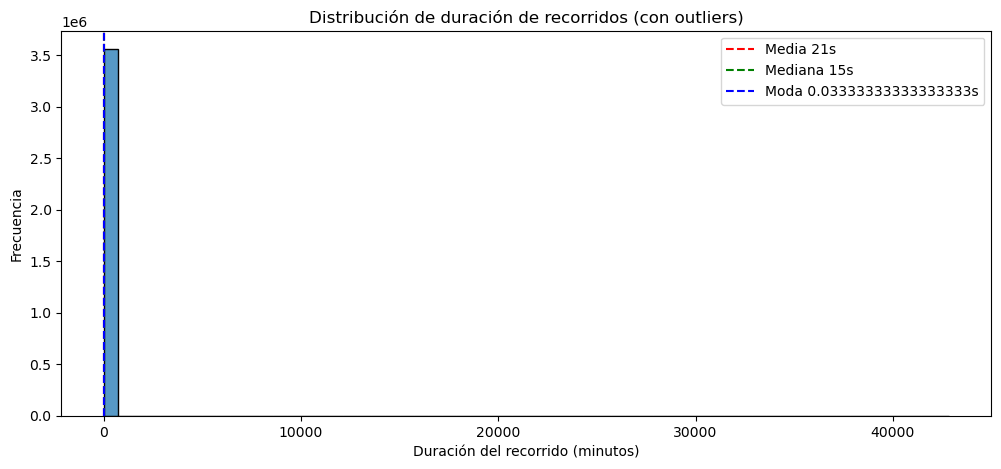

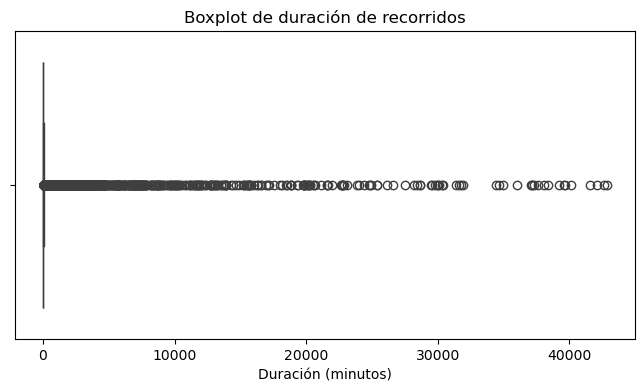

In [61]:
# Estadísticos básicos para la duración del recorrido
media = df["duracion_minutos"].mean()
mediana = df["duracion_minutos"].median()
moda = df["duracion_minutos"].mode()[0]
varianza = df["duracion_minutos"].var()
desv = df["duracion_minutos"].std()

print("Estadísticos de duración de viajes (sin filtros y en minutos)")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación estándar: {desv:.2f}")

# Histograma CON OUTLIERS 
plt.figure(figsize=(12,5))
sns.histplot(df["duracion_minutos"], bins=60, kde=False)
plt.axvline(media, color='red', linestyle='--', label=f'Media {media:.0f}s')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana {mediana:.0f}s')
plt.axvline(moda, color='blue', linestyle='--', label=f'Moda {moda}s')
plt.xlabel("Duración del recorrido (minutos)")
plt.ylabel("Frecuencia")
plt.title("Distribución de duración de recorridos (con outliers)")
plt.legend()
plt.show()

# Boxplot con outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df["duracion_minutos"])
plt.xlabel("Duración (minutos)")
plt.title("Boxplot de duración de recorridos")
plt.show()


Estadísticos de duración de viajes (en minutos)
Media: 19.98
Mediana: 15.87
Moda: 8.333333333333334
Varianza: 238.78
Desviación estándar: 15.45


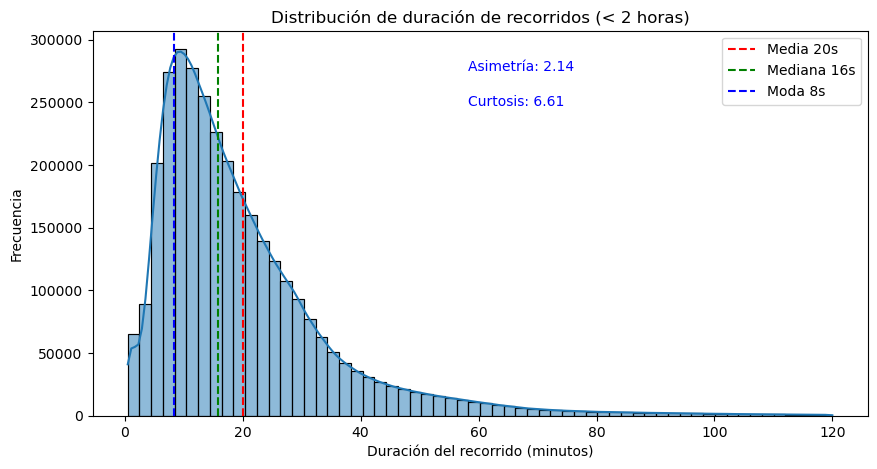

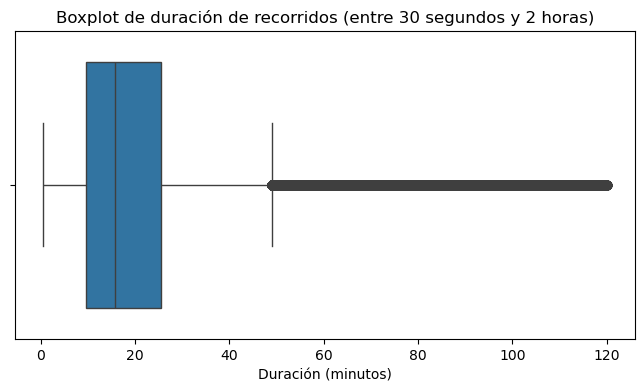

In [62]:

# Sobre la duración de los viajes

# Se hace un filtrado de viajes razonables 


# Estadísticos sin outliers para la duración del recorrido
media = df_filtrado["duracion_minutos"].mean()
mediana = df_filtrado["duracion_minutos"].median()
moda = df_filtrado["duracion_minutos"].mode()[0]
varianza = df_filtrado["duracion_minutos"].var()
desv = df_filtrado["duracion_minutos"].std()

print("Estadísticos de duración de viajes (en minutos)")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda: {moda}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación estándar: {desv:.2f}")

skewness = df_filtrado["duracion_minutos"].skew()
kurtosis = df_filtrado["duracion_minutos"].kurt()

plt.figure(figsize=(10,5))
sns.histplot(df_filtrado["duracion_minutos"], bins=60, kde=True)
plt.xlabel("Duración del recorrido (minutos)")
plt.ylabel("Frecuencia")
plt.axvline(df_filtrado["duracion_minutos"].mean(), color='red', linestyle='--', label=f'Media {media:.0f}s')
plt.axvline(df_filtrado["duracion_minutos"].median(), color='green', linestyle='--', label=f'Mediana {mediana:.0f}s')
plt.axvline(df_filtrado["duracion_minutos"].mode()[0], color='blue', linestyle='--', label=f'Moda {moda:.0f}s')

plt.figtext(0.5, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
plt.figtext(0.5, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
plt.title("Distribución de duración de recorridos (< 2 horas)")
plt.legend()
plt.show()

# Boxplot para ver valores atípicos
plt.figure(figsize=(8,4))
sns.boxplot(x=df_filtrado["duracion_minutos"])
plt.xlabel("Duración (minutos)")
plt.title("Boxplot de duración de recorridos (entre 30 segundos y 2 horas)")
plt.show()


In [63]:
# Sigue habiendo algunos outliers, pero muchos menos.

Q2 = df_filtrado['duracion_minutos'].quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
Q1 = df_filtrado['duracion_minutos'].quantile(0.25)
Q3 = df_filtrado['duracion_minutos'].quantile(0.75)

print("Q1 (25%):", Q1)
print("Q2 (Mediana, 50%):", Q2)
print("Q3 (75%):", Q3)

IQR = Q3 - Q1
print("Rango intercuartil (IQR):", IQR)

Q1 (25%): 9.7
Q2 (Mediana, 50%): 15.866666666666667
Q3 (75%): 25.45
Rango intercuartil (IQR): 15.75


<Axes: xlabel='duracion_minutos'>

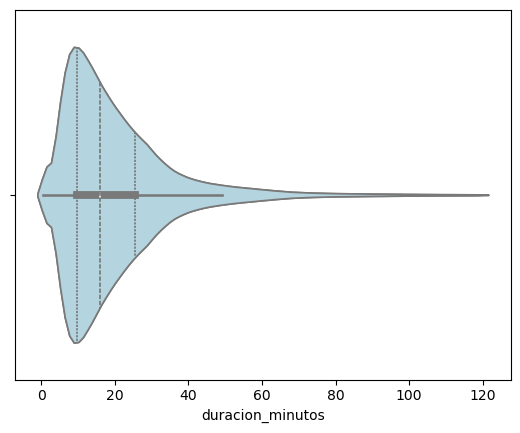

In [64]:
sns.violinplot(data=df_filtrado, x='duracion_minutos', color="lightblue", inner="box")
sns.violinplot(data=df_filtrado, x='duracion_minutos', color="lightblue", inner="quartile")

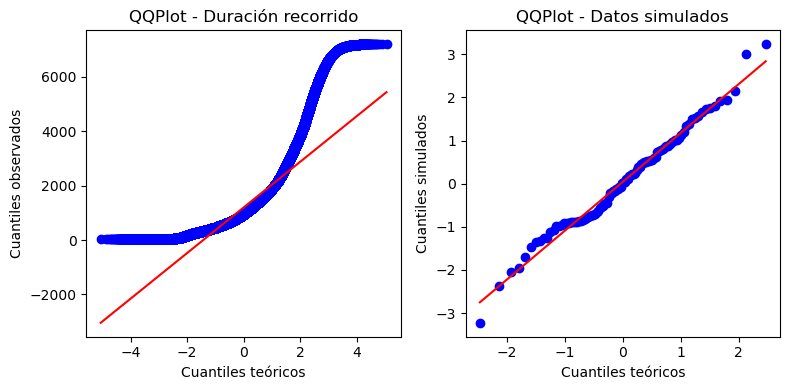

In [65]:
fig, (ax_ping, ax_normal) = plt.subplots(1, 2, figsize=(8, 4))

# QQPlot para la duración de recorrido
st.probplot(df_filtrado['duracion_recorrido'], dist="norm", plot=ax_ping)
ax_ping.set_title("QQPlot - Duración recorrido")
ax_ping.set_xlabel("Cuantiles teóricos")
ax_ping.set_ylabel("Cuantiles observados")

# QQPlot para datos aleatorios con distribución normal
data = np.random.normal(loc=0, scale=1, size=100)
st.probplot(data, dist="norm", plot=ax_normal)
ax_normal.set_title("QQPlot - Datos simulados")
ax_normal.set_xlabel("Cuantiles teóricos")
ax_normal.set_ylabel("Cuantiles simulados")

plt.tight_layout()
plt.show()

In [66]:
# Observamos que el nombnre de las estaciones tienen el formato compuesto
# "001 - Nombre de la ESTACION"
# Cambiamos los formato de nombres de estaciones

# Los convertimos a "NOMBRE DE LA ESTACION"
df["nombre_estacion_origen"] = df["nombre_estacion_origen"].str.split("-", n=1).str[-1].str.strip().str.upper()
df["nombre_estacion_destino"] = df["nombre_estacion_destino"].str.split("-", n=1).str[-1].str.strip().str.upper()

In [67]:
# Agrupamos por estación, día y hora (flujo de salidas)
salidas = (
    df.groupby(["nombre_estacion_origen", "dia_semana", "hora_salida"])
    .size()
    .reset_index(name="cantidad_salidas")
)

llegadas = (
    df.groupby(["nombre_estacion_destino", "dia_semana", "hora_llegada"])
    .size()
    .reset_index(name="cantidad_llegadas")
)

In [68]:
# Agrupamos por estación, día y hora (flujo de salidas)
salidas = (
    df.groupby(["nombre_estacion_origen", "dia_semana", "hora_salida"])
    .size()
    .reset_index(name="cantidad_salidas")
)

llegadas = (
    df.groupby(["nombre_estacion_destino", "dia_semana", "hora_llegada"])
    .size()
    .reset_index(name="cantidad_llegadas")
)

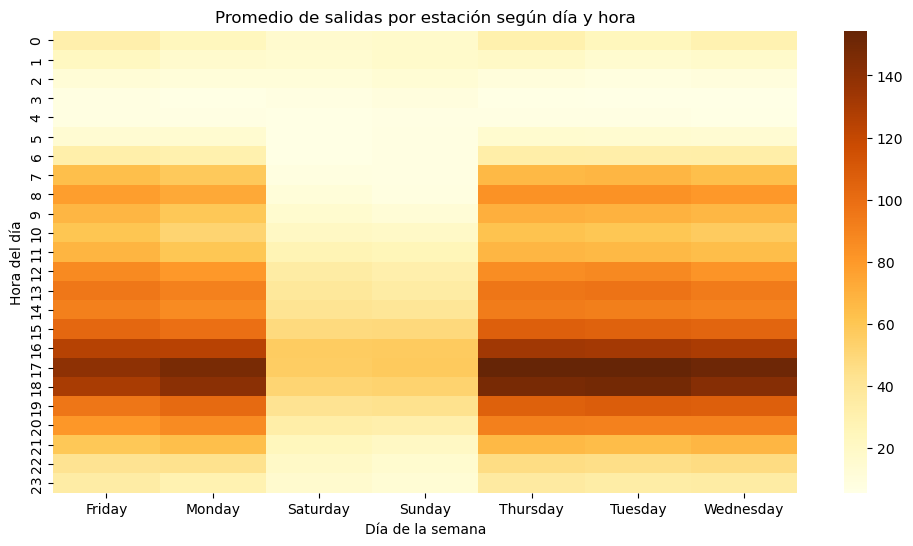

In [69]:
# Mapa de calor de las salidas: promedio de salidas por día y hora
pivot_salidas = salidas.pivot_table(
    index="hora_salida", columns="dia_semana", values="cantidad_salidas", aggfunc="mean"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_salidas, cmap="YlOrBr", annot=False)
plt.title("Promedio de salidas por estación según día y hora")
plt.ylabel("Hora del día")
plt.xlabel("Día de la semana")
plt.show()

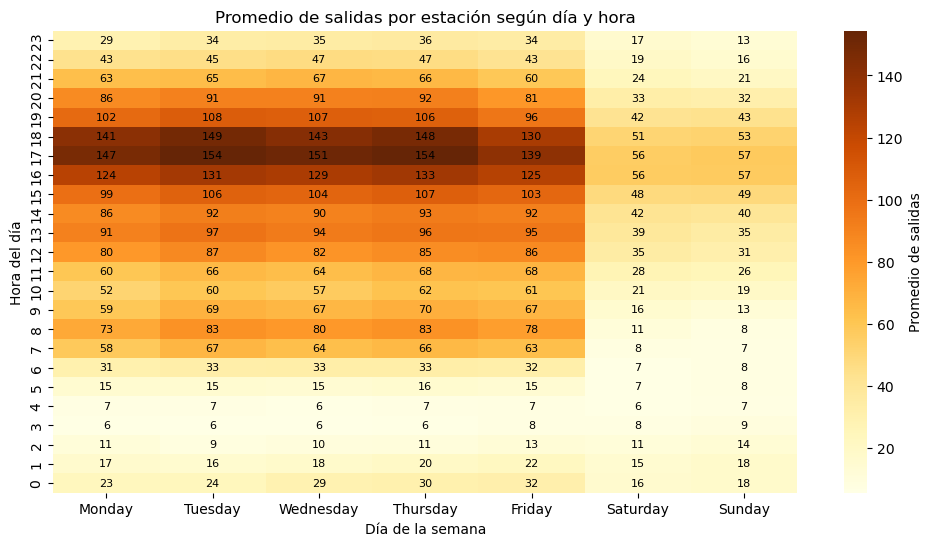

In [70]:
# Veamos los valores promedio en el mapa de calor.
# Definimos el orden de los días de la semana
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Reindexamos las columnas del pivot para ese orden
pivot_salidas = pivot_salidas[orden_dias]

plt.figure(figsize=(12,6))

# Con 'origin' invertimos el eje Y
sns.heatmap(
    pivot_salidas.sort_index(ascending=True),  # asegura que las horas estén en orden 0 → 23
    cmap="YlOrBr",
    annot=True,
    fmt=".0f",
    annot_kws={"size":8, "color":"black"},  # estilo de los números
    cbar_kws={'label': 'Promedio de salidas'},
)

plt.title("Promedio de salidas por estación según día y hora")
plt.ylabel("Hora del día")
plt.xlabel("Día de la semana")

# Invertir el eje Y (para que 00 esté abajo y 23 arriba)
plt.gca().invert_yaxis()
plt.show()

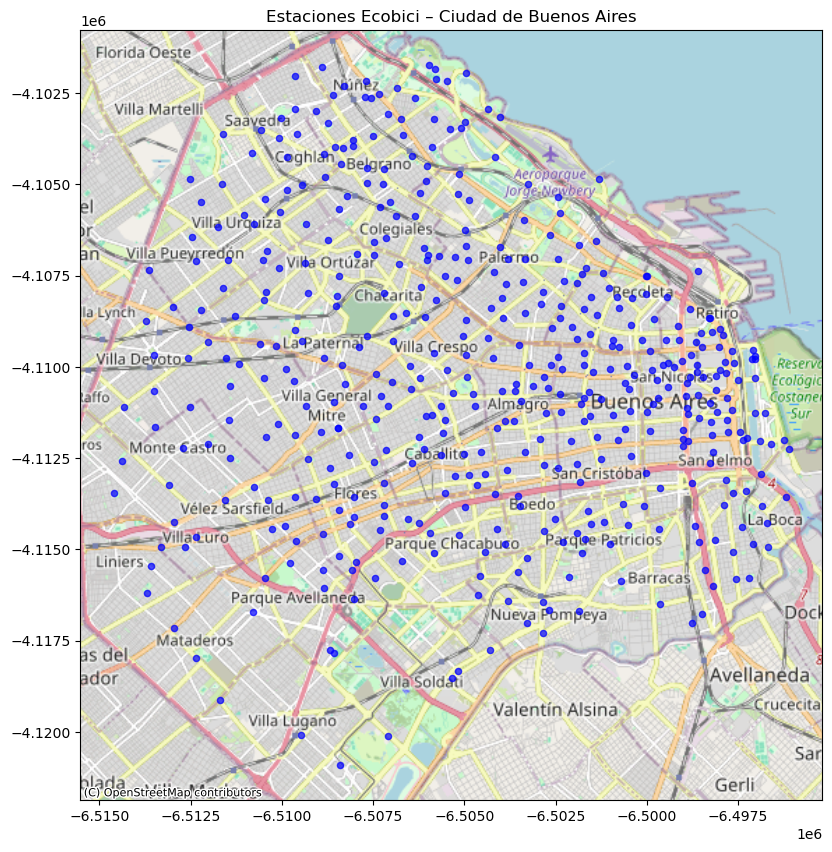

In [71]:
# Estaciones en el mapa de la ciudad

import geopandas as gpd
import contextily as ctx

# Archivo GeoJSON con estaciones
# https://cdn.buenosaires.gob.ar/datosabiertos/datasets/transporte-y-obras-publicas/estaciones-bicicletas-publicas/nuevas-estaciones-bicicletas-publicas.geojson
gdf = gpd.read_file("../datasets/estaciones_bicicletas_publicas.geojson")

# Convertir a Web Mercator (requerido por contextily)
gdf = gdf.to_crs(epsg=3857)

# Plot estaciones con mapa base
ax = gdf.plot(figsize=(10,10), color='blue', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Estaciones Ecobici – Ciudad de Buenos Aires")
plt.show()

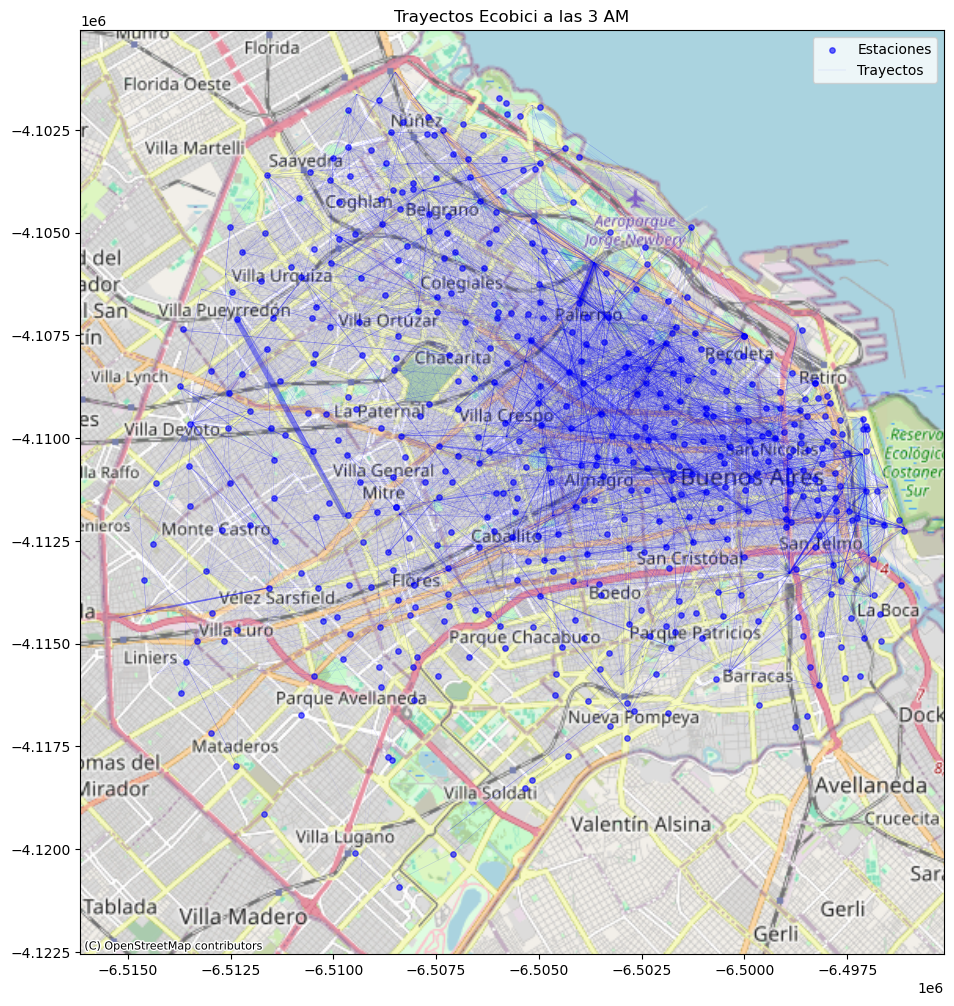

In [72]:
# Trayectos entre estaciones en un horario específico
from shapely.geometry import LineString

filtro_hora = 3 # 3 AM
df_filtrado = df[
    (df["hora_salida"] == filtro_hora)
    #& (df["dia_semana"] == 'Monday')
    ] # También se puede filtrar por día de la semana.

# Agrupamos por pares de estaciones
df_grouped = df_filtrado.groupby(
    ["id_estacion_origen", "id_estacion_destino",
     "long_estacion_origen", "lat_estacion_origen",
     "long_estacion_destino", "lat_estacion_destino"]
).size().reset_index(name="cantidad_viajes")

# Geometría de líneas
df_grouped["geometry"] = df_grouped.apply(
    lambda row: LineString([
        (row['long_estacion_origen'], row['lat_estacion_origen']),
        (row['long_estacion_destino'], row['lat_estacion_destino'])
    ]), axis=1
)

gdf_lines = gpd.GeoDataFrame(df_grouped, geometry="geometry", crs="EPSG:4326")

# Estaciones (geojson)
# ya están cargadas con 
# gdf = gpd.read_file("estaciones_bicicletas_publicas.geojson") y #gdf = gdf.to_crs(epsg=3857)

gdf_lines = gdf_lines.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(12,12))
gdf.plot(ax=ax, color="blue", markersize=15, alpha=0.6, label="Estaciones")

# Grosor proporcional a cantidad de viajes
gdf_lines.plot(
    ax=ax,
    linewidth=(gdf_lines["cantidad_viajes"] / gdf_lines["cantidad_viajes"].max()) * 5,
    alpha=0.4,
    color="blue",
    label="Trayectos"
)

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.title(f"Trayectos Ecobici a las {filtro_hora} {'AM' if filtro_hora < 12 else 'PM'}")
plt.legend()
plt.show()


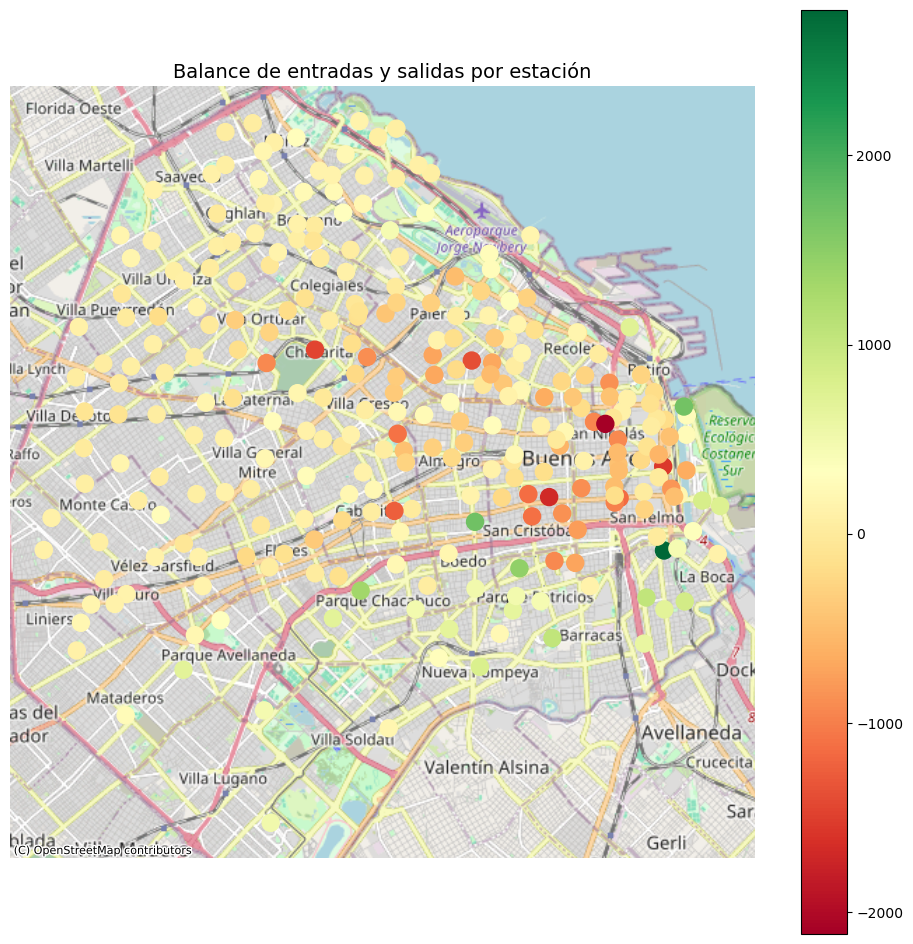

In [73]:
# Calculamos balance de entradas y salidas por estación

# Salidas
agregado = df.groupby('nombre_estacion_origen').size().reset_index(name='salidas')

# Llegadas
df_dest = df.groupby('nombre_estacion_destino').size().reset_index(name='llegadas')

# Merge salidas + llegadas
agg = pd.merge(
    agregado,
    df_dest,
    left_on='nombre_estacion_origen',
    right_on='nombre_estacion_destino',
    how='outer'
).fillna(0)

# Balance
agg['balance'] = agg['llegadas'] - agg['salidas']

# Estaciones con GeoJSON
merged = gdf.merge(agg, left_on='NOMBRE', right_on='nombre_estacion_origen')
merged = merged.to_crs(epsg=3857)

# Mapa base
fig, ax = plt.subplots(figsize=(12, 12))

merged.plot(
    column='balance',
    cmap='RdYlGn',
    legend=True,
    markersize=150,
    #alpha=0.8,
    ax=ax
)

# Agregar mapa de fondo
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Balance de entradas y salidas por estación", fontsize=14)
plt.show()

# Un balance muy negativo indica que la estación tiene más salidas que llegadas
# Esto puede sugerir que no son muy dispobles para tomar bicicletas?
# También podríamos realizar este análisis por horario. 

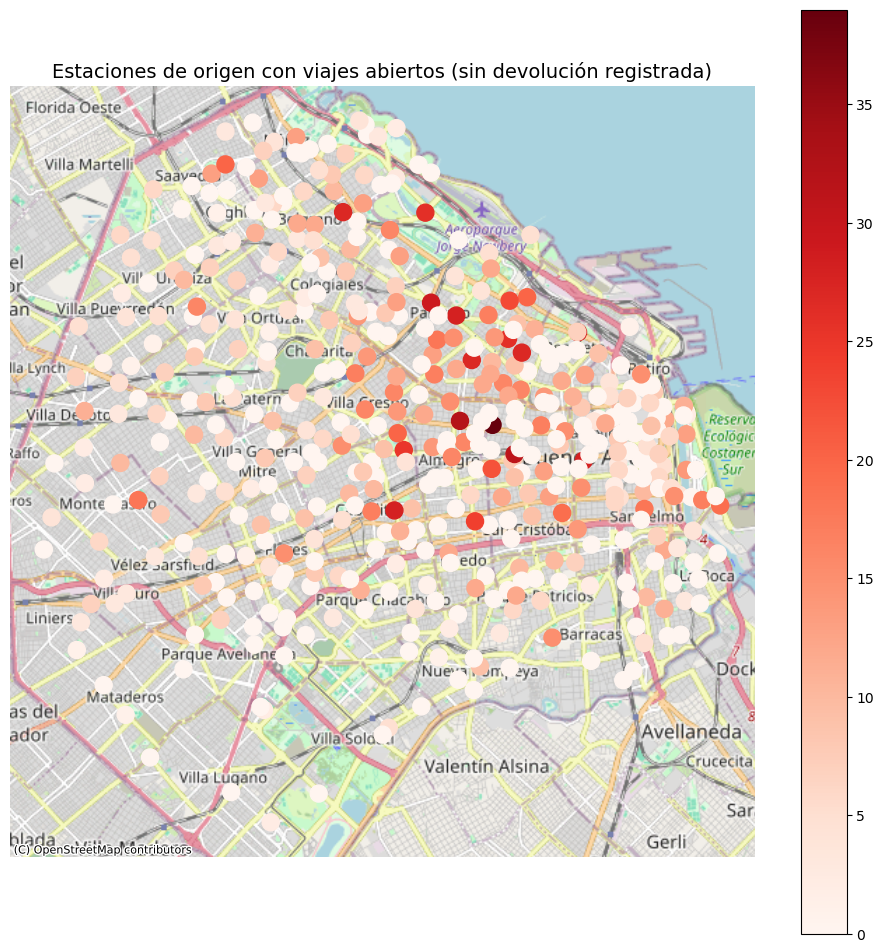

In [74]:

# columna target de viajes abiertos
df["viaje_abierto"] = df["fecha_destino_recorrido"].isna().astype(int)

# por estación de origen
abiertos = df.groupby("nombre_estacion_origen")["viaje_abierto"].sum().reset_index()
abiertos = abiertos.rename(columns={"viaje_abierto": "viajes_abiertos"})

# merge con estaciones
merged = gdf.merge(abiertos, left_on="NOMBRE", right_on="nombre_estacion_origen", how="left")
merged["viajes_abiertos"] = merged["viajes_abiertos"].fillna(0)  # en estaciones sin abiertos

# proyección métrica para usar contextily
merged = merged.to_crs(epsg=3857)

# graficamos
fig, ax = plt.subplots(figsize=(12, 12))

merged.plot(
    column="viajes_abiertos",
    cmap="Reds",
    legend=True,
    markersize=150,
    ax=ax
)

# mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Estaciones de origen con viajes abiertos (sin devolución registrada)", fontsize=14)
plt.show()

# 3) Plantear un posible problema de ML supervisado a partir de los datos elegidos.

- Describir el problema de clasificación o de regresión.

Clasificación: predicción de la duración del recorrido, dividimos en cuatro categorías, corto, medio, largo, muy largo

- Definir la variable target.

Podemos codificar, mediante label encoding, la variable target. Y para efectos de claridad la notamos así: 

C = Viaje corto, M = Viaje medio, L = Viaje largo, ML = Viaje muy largo 

# 4) Preprocesamiento y limpieza del dataset.

- Limpieza general

In [75]:
df.columns

Index(['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido',
       'id_estacion_origen', 'nombre_estacion_origen',
       'direccion_estacion_origen', 'long_estacion_origen',
       'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino',
       'nombre_estacion_destino', 'direccion_estacion_destino',
       'long_estacion_destino', 'lat_estacion_destino', 'id_usuario',
       'modelo_bicicleta', 'genero', 'dia_semana', 'hora_salida',
       'hora_llegada', 'duracion_minutos', 'duracion_calculada',
       'duracion_recorrido_diff', 'viaje_abierto'],
      dtype='object')

In [76]:
# borrar columnas temporales e innecesarias

df = df.drop(columns=["dia_semana", "hora_salida", "hora_llegada", "duracion_minutos", "duracion_calculada", "duracion_recorrido_diff", "viaje_abierto"])


- Split
- Tratamiento de faltantes y outliers

In [77]:
from sklearn.model_selection import train_test_split

df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(df.shape, test_df.shape)

(2847427, 17) (711857, 17)


## Lógica de detección y tratamiento de outliers en `duracion_recorrido`

1. **Definición de outliers estadísticos**  
   - Se aplica la **regla del IQR (Interquartile Range)** sobre los recorridos con duración > 0.  
   - Valores por debajo de `Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR` se consideran *outliers naturales*.  

2. **Reglas de negocio adicionales**  
   - Se descartan como inválidos los viajes con duración < **60 segundos** (movimientos espurios o errores de carga).  
   - Se descartan viajes con duración > **3 horas** (inconsistentes con la operación del sistema).  
   - También se marcan como outliers explícitos los recorridos con duración ≤ 0.  

3. **Construcción del conjunto de referencia (no-outliers)**  
   - Se filtran todos los casos marcados como outliers.  
   - Con el dataset limpio se calculan medias de duración para cada **par Origen–Destino (OD)**.  

4. **Imputación jerárquica**  
   - **Si un recorrido es outlier natural** → se reemplaza por la **media OD** calculada con los viajes válidos entre ese par de estaciones.  
   - **Si un recorrido es 0, negativo o no tiene media OD válida** → se reemplaza por la **mediana global** de todos los recorridos no outliers.  
   - Los recorridos válidos (no outliers) se conservan sin modificación.  

5. **Verificación posterior**  
   - Se asegura que no queden valores `NaN` ni duraciones igual a 0 en la columna imputada.  
   - Se comparan distribuciones (histogramas y boxplots) entre dataset original y dataset imputado para validar la reducción de extremos.  

---

✅ Con esta lógica, el tratamiento de outliers combina **robustez estadística (IQR)** con **conocimiento del dominio (reglas de negocio)** y un **fallback global confiable** para casos extremos.


In [78]:
COL = "duracion_recorrido"
KEYS = ["id_estacion_origen", "id_estacion_destino"]  # robusto vs lat/long

# =========================
# 1) Definir outliers (incluye ceros/negativos)
# =========================
dur_pos = df.loc[df[COL] > 0, COL]
Q1, Q3 = dur_pos.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 🚨 Aquí agregamos la regla de negocio
MIN_DUR = 60             # 1 minuto
MAX_DUR = 3 * 3600       # 3 horas
outliers_negocio = (df[COL] < MIN_DUR) | (df[COL] > MAX_DUR)

# Mask final = IQR + negocio + ceros/negativos explícitos
outliers_mask = outliers_negocio | (df[COL] <= 0) | (df[COL] < lower_bound) | (df[COL] > upper_bound)

print(f"[INFO] Outliers detectados: {outliers_mask.sum():,} de {len(df):,}")
print(f"[INFO] IQR límites (seg): lower={lower_bound:.2f}, upper={upper_bound:.2f}")
print(f"[INFO] Regla negocio: min={MIN_DUR}s, max={MAX_DUR/3600:.0f}h")

# =========================
# 2) Medias OD sin outliers (y >0)
# =========================
df_no_outliers = df.loc[(~outliers_mask) & (df[COL] > 0), KEYS + [COL]]

media_od = (
    df_no_outliers
    .groupby(KEYS, as_index=False)[COL]
    .mean()
    .rename(columns={COL: "duracion_media_od"})
)

# =========================
# 3) Merge & imputación a nuevo feature
# =========================
df_imputado = df.merge(media_od, on=KEYS, how="left")

# Fallback robusto: mediana global de no-outliers
mediana_global = df_no_outliers[COL].median()

# Paso intermedio (sin fallback) para auditoría
df_imputado["duracion_tmp"] = np.where(
    outliers_mask,
    df_imputado["duracion_media_od"],   # imputar con media OD
    df_imputado[COL]                    # conservar original si no es outlier
)

# Aplicar fallback global donde no hubo media OD
df_imputado["duracion_recorrido_imputado"] = df_imputado["duracion_tmp"].fillna(mediana_global)

# Seguridad: si por alguna razón queda <=0, reemplazar por mediana global
mask_residuo = df_imputado["duracion_recorrido_imputado"] <= 0
if mask_residuo.any():
    df_imputado.loc[mask_residuo, "duracion_recorrido_imputado"] = mediana_global

# =========================
# 4) Chequeos rápidos
# =========================
print("\n[CHECK] Calidad imputación")
print(" - NaN en duracion_tmp:", int(df_imputado["duracion_tmp"].isna().sum()))
print(" - NaN en imputado final:", int(df_imputado["duracion_recorrido_imputado"].isna().sum()))
print(" - Ceros originales:", int((df[COL] == 0).sum()))
print(" - Ceros en imputado final:", int((df_imputado["duracion_recorrido_imputado"] == 0).sum()))

# Resumen por par (opcional, útil para investigar pares problemáticos)
totales = df.groupby(KEYS).size().reset_index(name="count_total")
no_out = df_no_outliers.groupby(KEYS).size().reset_index(name="count_no_outliers")
faltantes = (
    df_imputado[df_imputado["duracion_tmp"].isna()]
    .groupby(KEYS).size().reset_index(name="count_nan")
)
pares_check = (
    totales.merge(no_out, on=KEYS, how="left")
           .merge(faltantes, on=KEYS, how="left")
           .fillna(0)
           .sort_values("count_nan", ascending=False)
)
print("[CHECK] Pares OD con NaN (top 5):")
print(pares_check.head(5))

# =========================
# 5) Boxplot SOLO de los imputados (outliers)
#     → para ver bigotes según IQR en los valores imputados
# =========================
imputados_only = df_imputado.loc[outliers_mask, "duracion_recorrido_imputado"].dropna()

# Estadísticos IQR de los imputados (por curiosidad)
Q1_imp, Q3_imp = imputados_only.quantile([0.25, 0.75])
IQR_imp = Q3_imp - Q1_imp
lb_imp = Q1_imp - 1.5 * IQR_imp
ub_imp = Q3_imp + 1.5 * IQR_imp
print(f"\n[BOX] Imputados: Q1={Q1_imp:.2f}, Q3={Q3_imp:.2f}, IQR={IQR_imp:.2f}, bigotes≈[{lb_imp:.2f}, {ub_imp:.2f}]")

plt.figure(figsize=(7,5))
plt.boxplot(imputados_only, labels=["Imputados (solo outliers)"])
plt.title("Boxplot de duraciones IMPUTADAS (con outliers tratados)")
plt.ylabel("Duración (segundos)")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df_imputado["duracion_recorrido_imputado"], labels=["Con imputación"], showfliers=False)
plt.title("Boxplot de la duración de recorridos (dataset completo, con imputación)")
plt.ylabel("Duración (segundos)")
plt.show()

# Histograma original
plt.figure(figsize=(8,5))
plt.hist(df[COL], bins=150, color="steelblue", alpha=0.7)
plt.title("Distribución original")
plt.xlabel("Duración (segundos)")
plt.ylabel("Frecuencia")
plt.show()

# Histograma con imputación
plt.figure(figsize=(8,5))
plt.hist(df_imputado["duracion_recorrido_imputado"], bins=150, color="seagreen", alpha=0.7)
plt.title("Distribución con imputación")
plt.xlabel("Duración imputada (segundos)")
plt.ylabel("Frecuencia")
plt.show()


[INFO] Outliers detectados: 416,868 de 2,847,427
[INFO] IQR límites (seg): lower=-963.00, upper=2949.00
[INFO] Regla negocio: min=60s, max=3h

[CHECK] Calidad imputación
 - NaN en duracion_tmp: 17438
 - NaN en imputado final: 0
 - Ceros originales: 29979
 - Ceros en imputado final: 0
[CHECK] Pares OD con NaN (top 5):
       id_estacion_origen  id_estacion_destino  count_total  \
21282                 121                  413           35   
677                     4                  453           21   
22089                 126                  275           18   
65072                 435                  284           18   
27547                 164                  531           18   

       count_no_outliers  count_nan  
21282                0.0       35.0  
677                  0.0       21.0  
22089                0.0       18.0  
65072                0.0       18.0  
27547                0.0       18.0  


AssertionError: 

In [ ]:
# al ser tan poco el porcentaje de nulos, y como es MCAR en el caso de género y una falla estructural en el caso de fecha destino, los podemos eliminar

print(df.size)
print(df_imputado.size) # ojo que estos quedan diferentes

missing = df.isna().sum().reset_index()
missing.columns = ["columna", "nulos"]
missing["porcentaje"] = (missing["nulos"] / len(df)) * 100

# Quedarnos solo con las que tienen faltantes
missing = missing[missing["nulos"] > 0].sort_values("nulos", ascending=False)
missing

df = df.dropna(subset=["genero", "fecha_destino_recorrido"])



45558832
54101113


# 5 ) Feature engeeneering

- Crear nuevos features 
    - podríamos crear columnas separadas para fecha de salida (mes, dia, hora)
- Discretizar
    - visualicemos el target el df imputado

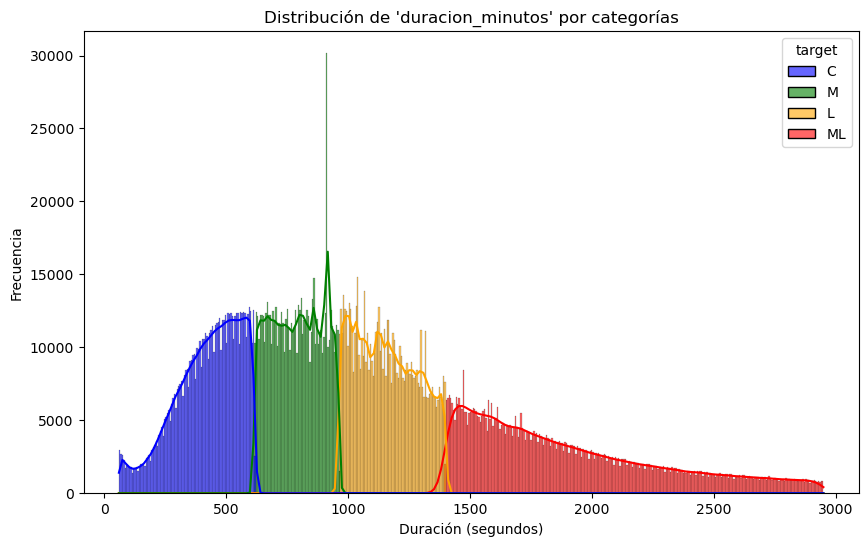

Puntos de corte de duración (minutos): [ 1.         10.25       16.03333333 23.31521991 49.15      ]
target
L     0.250573
C     0.250308
M     0.250145
ML    0.248974
Name: proportion, dtype: float64


In [ ]:
df_imputado["target"], bins = pd.qcut(df_imputado["duracion_recorrido_imputado"], q=4, labels=["C", "M", "L", "ML"], retbins=True)

# Visualicemos
plt.figure(figsize=(10,6))
sns.histplot(
    data=df_imputado, 
    x="duracion_recorrido_imputado",
    hue="target",
    palette=["blue", "green", "orange", "red"],
    bins=500,
    kde=True,
    alpha=0.6
)
plt.xlabel("Duración (segundos)")
plt.ylabel("Frecuencia")
plt.title("Distribución de 'duracion_minutos' por categorías")
plt.show()

# Ver los puntos de corte
print("Puntos de corte de duración (minutos):", bins/60)

# Ver distribución de clases
print(df_imputado["target"].value_counts(normalize=True))


- Encoding 
    - (Podemos usar cycling encoding para el mes si es que va)
    - label encoding para el target
    - standard encoding para variables numéricas

- Scaling
    - Standard scaler para numéricas

- Balance de clases no es necesario porque ya se hizo teniendo en cuenta que el target se discretiza por cuantiles

In [87]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df["target"], bins = pd.qcut(df_imputado["duracion_recorrido_imputado"], q=4, labels=["C", "M", "L", "ML"], retbins=True)

# --- Features derivadas de fecha ---
df["hora"] = df["fecha_origen_recorrido"].dt.hour
df["dia_semana"] = df["fecha_origen_recorrido"].dt.dayofweek  # 0=lunes, 6=domingo
df["mes"] = df["fecha_origen_recorrido"].dt.month

# --- Definir variables ---
features_numericas = ["hora", "dia_semana", "mes", "lat_estacion_origen", "long_estacion_origen"]
features_categoricas = ["id_estacion_origen", "modelo_bicicleta", "genero"]

# --- Target encoding ---
label_encoder = LabelEncoder()
df["target_encoded"] = label_encoder.fit_transform(df["target"])

# --- Separar X / y ---
X = df[features_numericas + features_categoricas]
y = df["target_encoded"]

# --- Preprocesamiento: escalado + one-hot ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas) # quizas es mejor usar target encoding para el id_estacion_origen?
    ]
)

# --- Pipeline general ---
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# --- Aplicar transformaciones ---
X_processed = pipeline.fit_transform(X)

print("Shape original:", X.shape)
print("Shape transformada:", X_processed.shape)

Shape original: (2847427, 8)
Shape transformada: (2847427, 406)


In [90]:
X_processed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 22779416 stored elements and shape (2847427, 406)>

In [ ]:
y.value_counts() 
# distribución de clases balanceada
# TODO VER ... quedaron 5 clases porqué? Muy probablemente por los outliers que no se pudieron imputar

target_encoded
1    570763
0    569669
4    569608
2    569349
3    568038
Name: count, dtype: int64

# 6 ) Reducción de la dimensionalidad

- Relaciones entre variables para selección de features



In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest,SelectFpr, f_classif 
selector_anova = SelectFpr(score_func=f_classif, alpha=0.05)

selector_anova.fit(X_processed, y)

print("Número de variables seleccionadas:", selector_anova.get_support().sum())

Número de variables seleccionadas: 160


In [101]:
label_encoder.classes_

array(['C', 'L', 'M', 'ML', nan], dtype=object)

- técnicas de extracción de features (ej: PCA). 

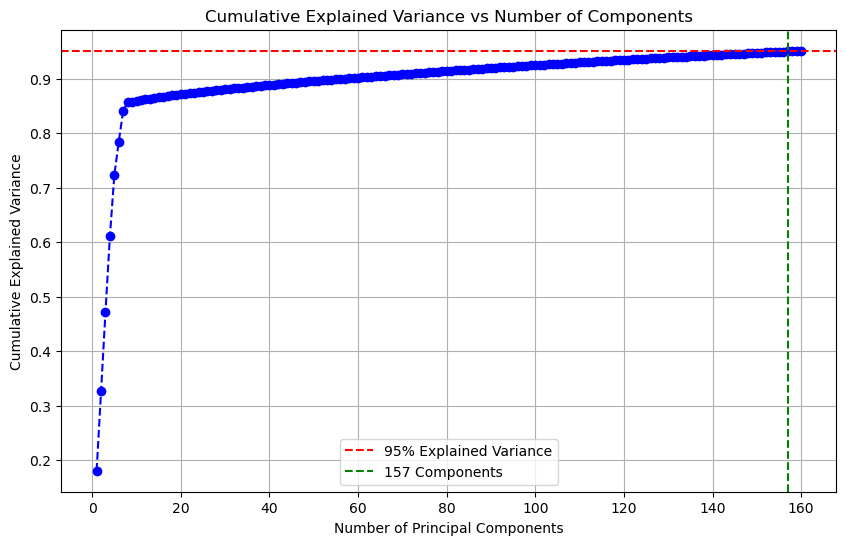

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=160)
X_train_pca = pca.fit_transform(X_processed)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada vs Número de Componentes')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza explicada')  
plt.axvline(x=np.argmax(cumulative_variance >= 0.95) + 1, color='g', linestyle='--', label=f'{np.argmax(cumulative_variance >= 0.95) + 1} Components')
plt.legend(loc='best')
plt.grid()
plt.show()